# Zadanie obowiązkowe [0-10] pkt

1. [0-1.5 pkt] Używając [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), dokonaj przeszukania przestrzeni hiperparametrów SVC, zmieniając (uargumentuj wybór):
   1. funkcję jądra
   1. paramety jądra
   1. parametr `C`
1. [0-1 pkt] W przeszukaniu wyżej użyj [walidacji krzyżowej](https://scikit-learn.org/stable/modules/cross_validation.html) odpowiedniej dla zbioru niezbalansowanego
1. [0-1.5 pkt] Zbadaj zależność liczby wektorów nośnych per klasa. W tym celu wykorzystaj atrybuty `support_vectors_` i/lub `decision_function`. Czy istnieje korelacja między liczbą wektorów nośnych a dokładnością klasyfikatora?
2. [0-1 pkt] Podobnie jak w poprzednim zadaniu, zbadaj dokładność modelu w zależności od techniki skalowania oraz wyboru liczby cech
3. [0-1.5 pkt] Dla najlepszej pary `n_features_to_select=2` wyrysuj obszary decyzyjne. Weź pod uwagę, że implementacja w `scikit-learn`  działa na zasadzie OvR (*One-vs-Rest*) tzn. każdy klasyfikator uczy się oddzielnej hiperpowierzchni dla swojej klasy. Skomentuj wyniki
1. [0-1 pkt] Porównaj wyniki najlepszego modelu z `LinearSVC` z domyślnymi parametrami. Użyj MCC jako miary do porównania (uwzględnij odchylenie standardowe po podziałach w walidacji krzyżowej). Skomentuj wynik
1. [0-1 pkt] Czy w świetle uzyskanych wyników, SVC jest odpowiednim klasyfikatorem do tego problemu? Uzasadnij odpowiedź
1. [0-1.5 pkt] Zidentyfikuj używkę, z którą model radzi sobie najlepiej. Analiza nie musi być tak zaawansowana jak wyżej, ale powinna miarodajnie porównać wszystkie klasyfikatory między sobą. Efektywnie, chodzi o zaimplementowanie pętli po zmiennej `y` i odpowiednie dobranie parametrów w `GridSearchCV` oraz `Pipeline`
   
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**.

## Przygotowanie danych

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from ucimlrepo import fetch_ucirepo
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder,StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.svm import LinearSVC, SVC

In [2]:
drugs = fetch_ucirepo(id=373) 
X = drugs.data.features 
y_all = drugs.data.targets
# Przewidujemy doświadczenia z grzybami halucynogennymi
y = y_all.mushrooms

In [3]:
idx_to_drop = y_all[y_all['semer'] != 'CL0'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

In [4]:
idx_to_drop = y[y == 'CL6'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

In [5]:
label_encoder = LabelEncoder()
y_trans = label_encoder.fit_transform(y.values)

## GridSearch

In [6]:
# skf zamiast zwykłego KFold bo klasy są niezbalansowane (punkt 2)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'f1_macro': 'f1_macro',
    'mcc': 'matthews_corrcoef'
}

# kika słowników aby nie testować bezsensownych kombinacji
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2, 3], 'gamma': ['scale', 'auto']}
]

svc = SVC(max_iter=10000, random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=skf,
    scoring=scoring,
    refit='mcc',
    n_jobs=-1
)

# skf zarządza podziałem train/test więc przekazane jest X i y_trans
grid_search.fit(X, y_trans)
best_model = grid_search.best_estimator_
best_index = grid_search.best_index_
best_f1 = grid_search.cv_results_['mean_test_f1_macro'][best_index]
best_mcc = grid_search.cv_results_['mean_test_mcc'][best_index]

print(f"Najlepsze parametry: {grid_search.best_params_}")
print(f"Wynik F1: {best_f1:.4f}")
print(f"Wynik MCC: {best_mcc:.4f}")

Najlepsze parametry: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Wynik F1: 0.3141
Wynik MCC: 0.2642


Niskie wartości obu metryk przy jednoczesnym wyborze nieliniowego jądra RBF wskazują, że choć zbiór nie jest separowalny liniowo, to analizowane cechy zbyt silnie się nakładają lub zawierają za dużo szumu, aby klasyfikator mógł skutecznie rozróżniać klasy.

Widać jednak dużą poprawę w porównaniu z wynikami z laba, gdzie $(F1, mcc) =(0.19, 0.23)$.

## Zależność liczby wektorów nośnych

In [7]:
support_vectors = best_model.n_support_
total_support_vectors = np.sum(support_vectors)
total_samples = len(X)
sv_ratio = total_support_vectors / total_samples

print(f"Liczba wektorów nośnych dla poszczególnych klas: {support_vectors}")
print(f"Łączna liczba wektorów nośnych: {total_support_vectors} ({sv_ratio:.1%})")

Liczba wektorów nośnych dla poszczególnych klas: [832 186 258 270 112  39]
Łączna liczba wektorów nośnych: 1697 (90.6%)


Większa liczba wektorów nośnych zazwyczaj oznacza niższą skuteczność. Dzieje się tak dlatego, że kiedy jest duża ilość wektorów nośnych to klasy na siebie nachodzą, a model się overfittuje na zbiorze treningowym.

Użycie ponad 90% próbek treningowych jako wektorów nośnych oznacza, że algorytm traktuje prawie każdy punkt jako graniczny, czyli klasy w przestrzeni cech mocno na siebie się nakładają.

## Dokładność modelu w zależności od techniki skalowania

In [8]:
best_svc = SVC(C=1, gamma='scale', kernel='rbf', class_weight='balanced', max_iter=10000, random_state=42)

scalers = {
    "NoScaler": "passthrough",
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

# mamy 12 features
num_features_to_test = [2, 4, 6, 8, 10, 'all']

for scaler_name, scaler in scalers.items():
    print(f"Scaler: {scaler_name}")
    for k in num_features_to_test:
        pipeline = Pipeline([
            ('scaler', scaler),
            ('feature_selection', SelectKBest(score_func=f_classif, k=k)),
            ('svc', best_svc)
        ])

        cv_results = cross_validate(
            estimator=pipeline, 
            X=X, 
            y=y_trans, 
            cv=skf, 
            scoring=scoring,
            n_jobs=-1
        )

        mean_f1 = np.mean(cv_results['test_f1_macro'])
        mean_mcc = np.mean(cv_results['test_mcc'])

        print(f"\tFeatures: {k} -> F1: {mean_f1:.4f}, MCC: {mean_mcc:.4f}")

Scaler: NoScaler
	Features: 2 -> F1: 0.2283, MCC: 0.2125
	Features: 4 -> F1: 0.3136, MCC: 0.2631
	Features: 6 -> F1: 0.3110, MCC: 0.2683
	Features: 8 -> F1: 0.3189, MCC: 0.2756
	Features: 10 -> F1: 0.3117, MCC: 0.2656
	Features: all -> F1: 0.3141, MCC: 0.2642
Scaler: StandardScaler
	Features: 2 -> F1: 0.2269, MCC: 0.2105
	Features: 4 -> F1: 0.3070, MCC: 0.2599
	Features: 6 -> F1: 0.3106, MCC: 0.2665
	Features: 8 -> F1: 0.3137, MCC: 0.2718
	Features: 10 -> F1: 0.3104, MCC: 0.2659
	Features: all -> F1: 0.3113, MCC: 0.2624
Scaler: MinMaxScaler
	Features: 2 -> F1: 0.2202, MCC: 0.2028
	Features: 4 -> F1: 0.2938, MCC: 0.2529
	Features: 6 -> F1: 0.2913, MCC: 0.2466
	Features: 8 -> F1: 0.3048, MCC: 0.2569
	Features: 10 -> F1: 0.3002, MCC: 0.2537
	Features: all -> F1: 0.2964, MCC: 0.2487
Scaler: RobustScaler
	Features: 2 -> F1: 0.2283, MCC: 0.2127
	Features: 4 -> F1: 0.3095, MCC: 0.2592
	Features: 6 -> F1: 0.3045, MCC: 0.2562
	Features: 8 -> F1: 0.3082, MCC: 0.2623
	Features: 10 -> F1: 0.3078, 

Najlepszą skuteczność modelu osiągnięto bez skalowania (może dlatego, że już wcześniej dane zostały skwantyfikowane za pomocą CatPCA). Dodatkowo widać lekką poprawę po redukcji wymiarowości do 8 cech. Prawdopodobnie wyeliminowało to skutecznie część szumu względem pełnego zbioru.

## Obszary decyzyjne

In [9]:
k2best = SelectKBest(score_func=f_classif, k=2)
X_2d = k2best.fit_transform(X.values, y_trans)

In [10]:
selected_indices = k2best.get_support(indices=True)
feature_names = X.columns[selected_indices]
feature_names

Index(['age', 'country'], dtype='str')

In [11]:
model_2d = SVC(C=1, gamma='scale', kernel='rbf', class_weight='balanced', decision_function_shape='ovr', random_state=42)
model_2d.fit(X_2d, y_trans)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


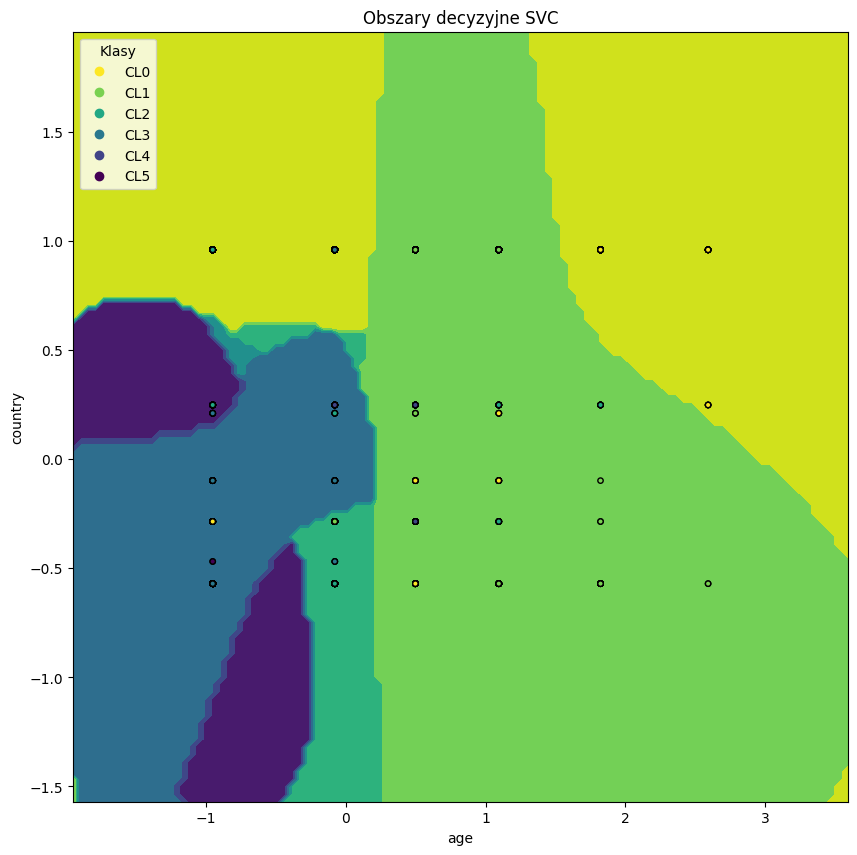

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

DecisionBoundaryDisplay.from_estimator(
    model_2d,
    X_2d,
    response_method="predict",
    cmap='viridis_r', 
    ax=ax,
    xlabel=feature_names[0],
    ylabel=feature_names[1]
)

scatter = ax.scatter(
    X_2d[:, 0], 
    X_2d[:, 1], 
    c=y_trans, 
    cmap='viridis_r', 
    edgecolors='k',
    s=15
)
plt.title("Obszary decyzyjne SVC")

handles, _ = scatter.legend_elements()
ax.legend(handles, label_encoder.inverse_transform(range(len(handles))), title="Klasy", loc='upper left')
plt.show()

### Znaczenie wartości:
Age:
 - około -1 => 18-24
 - około 0 => 25-34
 - około 0.5 => 35-44
 - około 1 => 45-54
 - około 2 => 55-64
 - około 2.5 => 65+

Country:
 - okolo -0.6 => USA
 - okolo -0.5 => NZ
 - okolo -0.3 => inne
 - okolo -0.1 => Australia
 - okolo 0.2 => Irlandia
 - okolo 0.25 => Canada
 - okolo 1 => UK

Wyniki:
 - CL0 => Nigdy
 - CL1 => ponad dekadę temu
 - CL2 => w tej dekadzie
 - CL3 => w tym roku
 - CL4 => w tym miesiącu
 - CL5 => w tym tygodniu

### Wnioski:
Widać, że dane układają się w regularną siatkę (skutek CatCPA). Sprawia to, że wiele punktów nakłada się na siebie w tych samych współrzędnych mimo różnych wartości. W takiej przestrzeni klasy są liniowo i nieliniowo nierozdzielne. Wykres pokazuje czemu wcześniej wyszedł taki słaby wynik i ponad 90% wektorów nośnych.

## Porównanie z `LinearSVC`

In [13]:
linear_svc = LinearSVC(max_iter=10000, random_state=42, class_weight='balanced', dual=False)

models = {
    "Best SVC (RBF)": best_svc,
    "Default LinearSVC": linear_svc
}

for name, model in models.items():
    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=y_trans,
        cv=skf,
        scoring='matthews_corrcoef',
        n_jobs=-1
    )
    
    mean_mcc = np.mean(cv_results['test_score'])
    std_mcc = np.std(cv_results['test_score'])
    
    print(f"Model: {name} => mean_mcc: {mean_mcc:.4f}, std_mcc: {std_mcc:.4f}")

Model: Best SVC (RBF) => mean_mcc: 0.2642, std_mcc: 0.0218
Model: Default LinearSVC => mean_mcc: 0.2775, std_mcc: 0.0300


Zaskakujące jest to, że model liniowy uzyskał lepszy wynik niż SVC (z RBF). Sureguje to, że prostszy model lepiej generalizuje niż jądro nieliniowe, które się ovefittuje do lokalnych skupisk punktów.

Widać za to, że RBC ma niższe odchylenie, które oznacza bardziej stabilny model w porówanniu z liniowym modelem.

## Skuteczność SVC w problemie

Uważam, że **SVC nie jest dobrym klasyfikatorem** tego problemu.

Uzasadnienie:
 - bardzo wysoki procent wektorów nośnych ($90.6\%$) oznacza, że problem nie potrafi znaleźć dobrze granicy między klasami i overfittuje się do próbki treningowej.
 - klasy mocno na siebie nachodzą, co widać w powyżej pokazanych obszarach decyzyjnych uniemożliwiając utworzenie poprawnych obszarów decyzyjych

## Inne używki

In [14]:
X = drugs.data.features
y_all = drugs.data.targets

idx_to_drop = y_all[y_all['semer'] != 'CL0'].index
X = X.drop(idx_to_drop)
y_all = y_all.drop(idx_to_drop)

num_features_to_test = [4, 8, 'all']
scalers_list = list(scalers.values())
param_grid = [
    {
        'scaler': scalers_list,
        'feature_selection__k': num_features_to_test,
        'svc__kernel': ['linear'], 
        'svc__C': [0.1, 1, 10]
    },
    {
        'scaler': scalers_list,
        'feature_selection__k': num_features_to_test,
        'svc__kernel': ['rbf'], 
        'svc__C': [0.1, 1, 10], 
        'svc__gamma': ['scale', 'auto']
    },
    {
        'scaler': scalers_list,
        'feature_selection__k': num_features_to_test,
        'svc__kernel': ['poly'], 
        'svc__C': [0.1, 1, 10], 
        'svc__degree': [2, 3], 
        'svc__gamma': ['scale', 'auto']
    }
]

for target in y_all:
    if target=="semer": continue
    
    # usuwamy za rzadkie klasy
    y = y_all[target]
    counts = y.value_counts()
    mask = y.map(y.value_counts()) >= 10
    X_target, y_target = X[mask.to_numpy()], y[mask.to_numpy()]

    # tworzymy pipeline
    pipeline = Pipeline([
        ('scaler', 'passthrough'),
        ('feature_selection', SelectKBest(score_func=f_classif)),
        ('svc', SVC(max_iter=10000, random_state=42, class_weight='balanced'))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=skf,
        scoring=scoring,
        refit='mcc',
        n_jobs=-1
    )
    grid_search.fit(X_target, y_target)

    best_index = grid_search.best_index_
    best_f1 = grid_search.cv_results_['mean_test_f1_macro'][best_index]
    best_mcc = grid_search.cv_results_['mean_test_mcc'][best_index]

    print(f"===== {target} =====")
    print(f"Najlepsze params: {grid_search.best_params_}")
    print(f"Wynik F1: {best_f1:.4f}")
    print(f"Wynik MCC: {best_mcc:.4f}\n")

c:\Users\piotr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


===== alcohol =====
Najlepsze params: {'feature_selection__k': 'all', 'scaler': 'passthrough', 'svc__C': 10, 'svc__degree': 3, 'svc__gamma': 'auto', 'svc__kernel': 'poly'}
Wynik F1: 0.1899
Wynik MCC: 0.0915

===== amphet =====
Najlepsze params: {'feature_selection__k': 8, 'scaler': 'passthrough', 'svc__C': 1, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}
Wynik F1: 0.2772
Wynik MCC: 0.2318

===== amyl =====
Najlepsze params: {'feature_selection__k': 'all', 'scaler': StandardScaler(), 'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Wynik F1: 0.2550
Wynik MCC: 0.2257

===== benzos =====
Najlepsze params: {'feature_selection__k': 8, 'scaler': RobustScaler(), 'svc__C': 1, 'svc__kernel': 'linear'}
Wynik F1: 0.2363
Wynik MCC: 0.1971

===== caff =====
Najlepsze params: {'feature_selection__k': 'all', 'scaler': StandardScaler(), 'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Wynik F1: 0.1440
Wynik MCC: 0.0645

===== cannabis =====
Najlepsze params: {'feature_selection__k': 8,

c:\Users\piotr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


===== crack =====
Najlepsze params: {'feature_selection__k': 4, 'scaler': RobustScaler(), 'svc__C': 10, 'svc__degree': 3, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}
Wynik F1: 0.3405
Wynik MCC: 0.2056

===== ecstasy =====
Najlepsze params: {'feature_selection__k': 'all', 'scaler': MinMaxScaler(), 'svc__C': 0.1, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}
Wynik F1: 0.1533
Wynik MCC: 0.2202

===== heroin =====
Najlepsze params: {'feature_selection__k': 'all', 'scaler': RobustScaler(), 'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Wynik F1: 0.2010
Wynik MCC: 0.2000

===== ketamine =====
Najlepsze params: {'feature_selection__k': 8, 'scaler': MinMaxScaler(), 'svc__C': 10, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}
Wynik F1: 0.1965
Wynik MCC: 0.1516

===== legalh =====
Najlepsze params: {'feature_selection__k': 'all', 'scaler': StandardScaler(), 'svc__C': 0.1, 'svc__degree': 3, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}
Wynik F1: 0.2382
Wynik MCC: 0.2781

===== lsd =====
N

Opierając się na `mcc` najlepszy wynik ma `LSD` (MCC = **0.3146**) - jest to dalej wynik niski.

Dla substancji powszechnie dostępnych (np. alkohol, kofeina lub czekolada) nawet najlepszy model z tego GridSearcha radzi sobie nie dużo lepiej niż losowe zgadywanie.

Wnioskiem może być to, że nie da się dobrze przewidzieć konsumcji używek (lub innych substancji) za pomocą SVC używając tylko danych demograficznych i testów psychologicznych.